# Задание 4

Зададим некоторое значение $\lambda_{\text{true}} > 0$ и сгенерируем выборку из $N = 10^3$ значений из распределения $\text{Pois}(\lambda_{\text{true}})$. Нужно написать код, который реализует алгоритм бутстрепа для этой выборки и построение 95\% перцентильного доверительного интервала, построить гистограмму полученного распределения оценок и отобразить на графике требуемый доверительный интервал. Оценку для параметра $\lambda_{\text{true}}$  стоит взять как оценку максимального правдоподобия для данного распределения.


In [3]:
import numpy as np
import scipy.stats as sts
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#
# в задании 1 мы искали maximum likelihood оценку для параметра lambda, и получили, что это x.mean()
#

In [153]:
class Bootstrap:
    def __init__(self, lam_true = 3, N = 1e3, B = 1e4):
        #
        # lam_true - lambda to generate a sample from Pois(lam_true)
        # N - sample size
        # B - number of bootstrap samples
        #
        self.lam_true = lam_true
        self.N = int(N)
        self.B = int(B)
        self.sample = np.random.poisson(lam = lam_true, size = self.N)
        self.lambdas = []
        self.lower_bound = self.upper_bound = None
        self.percent = None

    def get_param_distr(self):
        for i in range(self.B):
            new_sample = np.random.choice(self.sample, size = self.N, replace = True)
            self.lambdas.append(new_sample.mean())

        self.lambdas = np.array(sorted(self.lambdas))

    def CI(self, percent = 0.95):
        self.percent = percent
        if self.percent > 1:
            self.percent = percent / 100
        self.lower_bound = int(self.B * (1 - self.percent) / 2)
        self.upper_bound = int(self.B * (1 - (1 - self.percent) / 2))

        print(f'we are 95% sure lambda true lies between {self.lambdas[self.lower_bound]} and {self.lambdas[self.upper_bound]}')

        return self.lambdas[self.lower_bound], self.lambdas[self.upper_bound]

    def draw_histogram(self, color = 'sandybrown'):
        figure, ax = plt.subplots(figsize = (10,8))
        ax.set_facecolor('snow')
        ax.hist(self.lambdas, bins = 50, color = color)
        ax.axvline(x = self.lambdas[self.lower_bound], ls = '--', lw = 3, color = 'black')
        ax.axvline(x = self.lambdas[self.upper_bound], ls = '--', lw = 3, color = 'black')
        ax.axvspan( self.lambdas.min(),  self.lambdas[self.lower_bound], color='snow', alpha = 0.5)
        ax.axvspan(self.lambdas[self.upper_bound],  self.lambdas.max(), color='snow', alpha = 0.5)
        plt.title(f'{int(self.percent*100)}% confidence interval: {self.lambdas[self.lower_bound]:.2f} - {self.lambdas[self.upper_bound]:.2f}', size = 16)
        plt.show()



we are 95% sure lambda true lies between 2.904 and 3.113


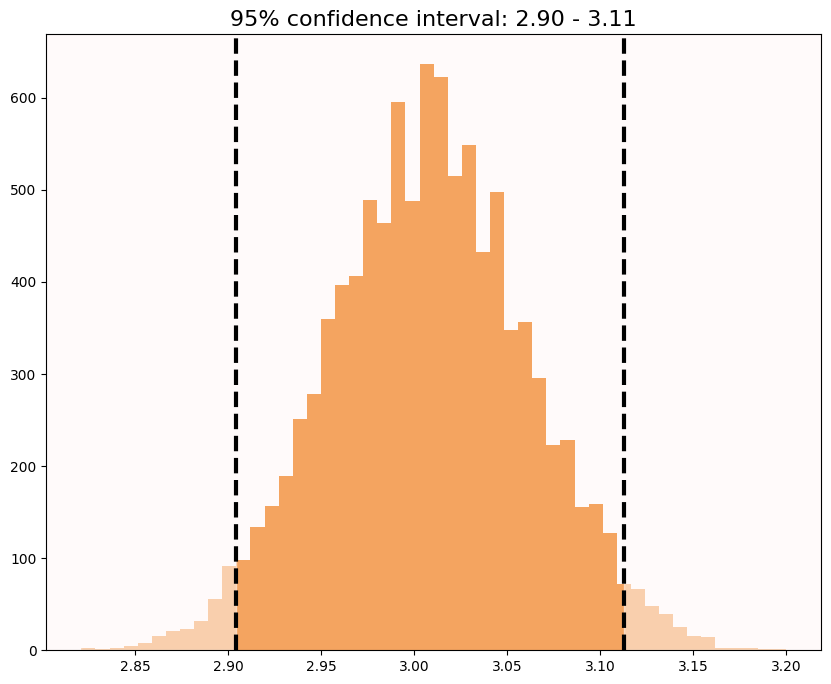

In [154]:
# пример с параметрами по дефолту

b = Bootstrap()
b.get_param_distr()
b.CI()
b.draw_histogram()

we are 95% sure lambda true lies between 4.9549 and 5.072


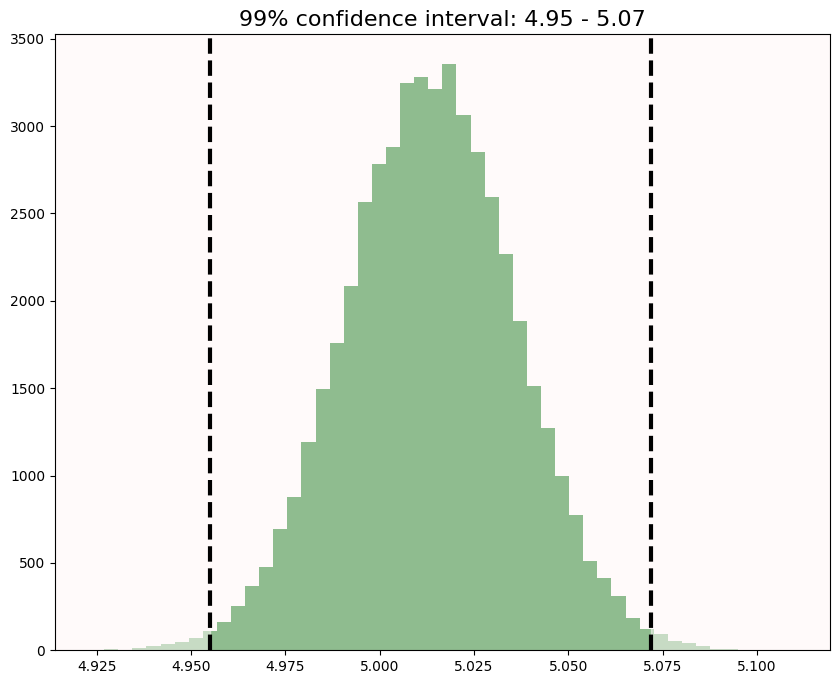

In [155]:
# lambda = 5
# N = 1e4
# B = 5e4

b = Bootstrap(5, 1e4, 5e4)
b.get_param_distr()

# 99$ CI

b.CI(0.99)
b.draw_histogram('darkseagreen')

we are 95% sure lambda true lies between 9.69 and 10.017


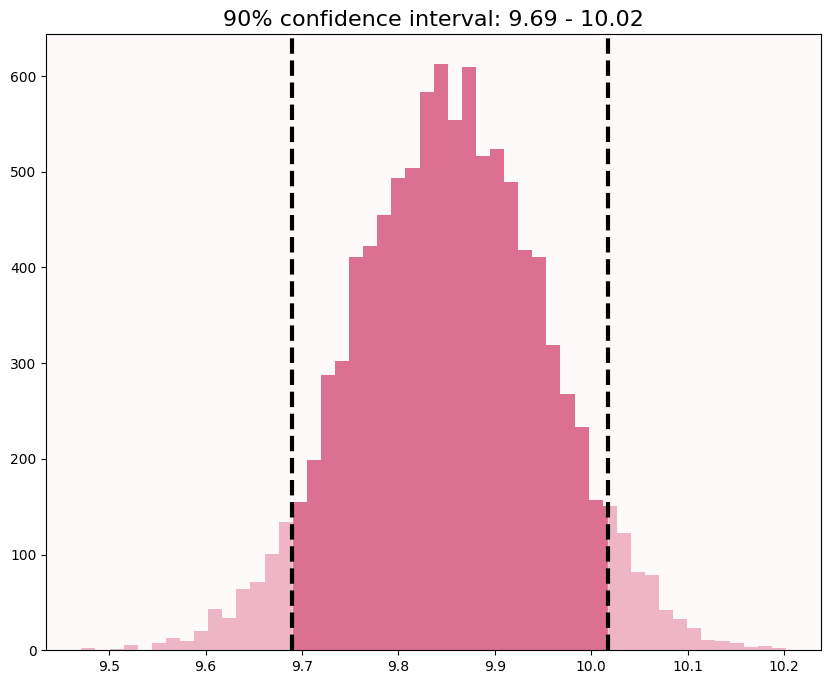

In [156]:
# lambda = 5

b = Bootstrap(10)
b.get_param_distr()

# 90% CI
b.CI(0.90)
b.draw_histogram('palevioletred')